In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data.csv")
df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


In [3]:
df.shape

(32, 5)

In [4]:
df.columns

Index(['Duration', 'Date', 'Pulse', 'Maxpulse', 'Calories'], dtype='object')

In [5]:
df.dtypes

,0
Duration,int64
Date,object
Pulse,int64
Maxpulse,int64
Calories,float64


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     object 
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.4+ KB


In [7]:
df.describe()

,Duration,Pulse,Maxpulse,Calories
count,32.000000,32.000000,32.000000,30.000000
mean,68.437500,103.500000,128.500000,304.680000
std,70.039591,7.832933,12.998759,66.003779
min,30.000000,90.000000,101.000000,195.100000
25%,60.000000,100.000000,120.000000,250.700000
50%,60.000000,102.500000,127.500000,291.200000
75%,60.000000,106.500000,132.250000,343.975000
max,450.000000,130.000000,175.000000,479.000000


In [8]:
df.isnull().sum()

,0
Duration,0
Date,1
Pulse,0
Maxpulse,0
Calories,2


In [9]:
df["Date"] = pd.to_datetime(
    df["Date"].astype(str).str.strip("'"),
    format="mixed",
    errors="coerce"
)

In [10]:
df["Date"].isnull().sum()

np.int64(1)

In [11]:
missing_date_index = df["Date"].isna()

df.loc[missing_date_index, "Date"] = pd.Timestamp("2020-12-22")

In [12]:
df["Date"].isnull().sum()

np.int64(0)

In [13]:
calories_median = df["Calories"].median()
calories_median

291.2

In [14]:
df["Calories"] = df["Calories"].fillna(calories_median)

In [15]:
df.isnull().sum()

,0
Duration,0
Date,0
Pulse,0
Maxpulse,0
Calories,0


In [16]:
df.duplicated().sum()

np.int64(1)

In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(31, 5)

In [20]:
df["Date"].sort_values().head()

,Date
0,2020-12-01
1,2020-12-02
2,2020-12-03
3,2020-12-04
4,2020-12-05


In [21]:
df["Date"].sort_values().tail()

,Date
27,2020-12-27
28,2020-12-28
29,2020-12-29
30,2020-12-30
31,2020-12-31


In [22]:
df["Duration"].describe()

,Duration
count,31.000000
mean,68.709677
std,71.180144
min,30.000000
25%,60.000000
50%,60.000000
75%,60.000000
max,450.000000


In [23]:
df[df["Duration"] > 120]

,Duration,Date,Pulse,Maxpulse,Calories
7,450,2020-12-08,104,134,253.3


In [24]:
df["Calories_per_Minute"] = df["Calories"] / df["Duration"]

In [25]:
df[["Duration", "Calories", "Calories_per_Minute"]].head()

,Duration,Calories,Calories_per_Minute
0,60,409.1,6.818333
1,60,479.0,7.983333
2,60,340.0,5.666667
3,45,282.4,6.275556
4,45,406.0,9.022222


In [26]:
df["Pulse_Category"] = pd.cut(
    df["Pulse"],
    bins=[0, 99, 109, float("inf")],
    labels=["Low", "Moderate", "High"]
)

In [27]:
df[["Pulse", "Pulse_Category"]].head(10)

,Pulse,Pulse_Category
0,110,High
1,117,High
2,103,Moderate
3,109,Moderate
4,117,High
5,102,Moderate
6,110,High
7,104,Moderate
8,109,Moderate
9,98,Low


In [28]:
high_pulse = df[df["Pulse"] > 110]
high_pulse

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute,Pulse_Category
1,60,2020-12-02,117,145,479.0,7.983333,High
4,45,2020-12-05,117,148,406.0,9.022222,High
23,60,2020-12-23,130,101,300.0,5.000000,High


In [29]:
high_calories = df[df["Calories"] > 300]
high_calories

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute,Pulse_Category
0,60,2020-12-01,110,130,409.1,6.818333,High
1,60,2020-12-02,117,145,479.0,7.983333,High
2,60,2020-12-03,103,135,340.0,5.666667,Moderate
4,45,2020-12-05,117,148,406.0,9.022222,High
6,60,2020-12-07,110,136,374.0,6.233333,High
10,60,2020-12-11,103,147,329.3,5.488333,Moderate
13,60,2020-12-13,106,128,345.3,5.755000,Moderate
14,60,2020-12-14,104,132,379.3,6.321667,Moderate
19,60,2020-12-19,103,123,323.0,5.383333,Moderate
21,60,2020-12-21,108,131,364.2,6.070000,Moderate


In [30]:
long_workouts = df[df["Duration"] >= 60]
long_workouts

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute,Pulse_Category
0,60,2020-12-01,110,130,409.1,6.818333,High
1,60,2020-12-02,117,145,479.0,7.983333,High
2,60,2020-12-03,103,135,340.0,5.666667,Moderate
5,60,2020-12-06,102,127,300.0,5.000000,Moderate
6,60,2020-12-07,110,136,374.0,6.233333,High
7,450,2020-12-08,104,134,253.3,0.562889,Moderate
9,60,2020-12-10,98,124,269.0,4.483333,Low
10,60,2020-12-11,103,147,329.3,5.488333,Moderate
11,60,2020-12-12,100,120,250.7,4.178333,Moderate
13,60,2020-12-13,106,128,345.3,5.755000,Moderate


In [31]:
filtered_data = df[
    (df["Duration"] >= 60) &
    (df["Calories"] > 300)
]

filtered_data

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute,Pulse_Category
0,60,2020-12-01,110,130,409.1,6.818333,High
1,60,2020-12-02,117,145,479.0,7.983333,High
2,60,2020-12-03,103,135,340.0,5.666667,Moderate
6,60,2020-12-07,110,136,374.0,6.233333,High
10,60,2020-12-11,103,147,329.3,5.488333,Moderate
13,60,2020-12-13,106,128,345.3,5.755000,Moderate
14,60,2020-12-14,104,132,379.3,6.321667,Moderate
19,60,2020-12-19,103,123,323.0,5.383333,Moderate
21,60,2020-12-21,108,131,364.2,6.070000,Moderate
25,60,2020-12-25,102,126,334.5,5.575000,Moderate


In [32]:
df.sort_values("Calories", ascending=False).head(10)

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute,Pulse_Category
1,60,2020-12-02,117,145,479.0,7.983333,High
0,60,2020-12-01,110,130,409.1,6.818333,High
4,45,2020-12-05,117,148,406.0,9.022222,High
30,60,2020-12-30,102,129,380.3,6.338333,Moderate
14,60,2020-12-14,104,132,379.3,6.321667,Moderate
6,60,2020-12-07,110,136,374.0,6.233333,High
21,60,2020-12-21,108,131,364.2,6.070000,Moderate
13,60,2020-12-13,106,128,345.3,5.755000,Moderate
2,60,2020-12-03,103,135,340.0,5.666667,Moderate
25,60,2020-12-25,102,126,334.5,5.575000,Moderate


In [33]:
df[["Duration", "Pulse", "Maxpulse", "Calories"]].mean()

,0
Duration,68.709677
Pulse,103.612903
Maxpulse,128.774194
Calories,305.551613


In [34]:
df[["Duration", "Pulse", "Maxpulse", "Calories"]].max()

,0
Duration,450.0
Pulse,130.0
Maxpulse,175.0
Calories,479.0


In [35]:
df[["Duration", "Pulse", "Maxpulse", "Calories"]].min()

,0
Duration,30.0
Pulse,90.0
Maxpulse,101.0
Calories,195.1


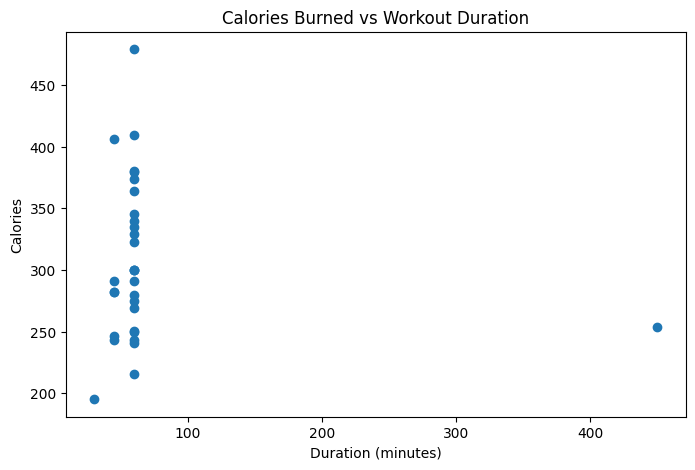

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(df["Duration"], df["Calories"])

plt.xlabel("Duration (minutes)")
plt.ylabel("Calories")
plt.title("Calories Burned vs Workout Duration")

plt.show()

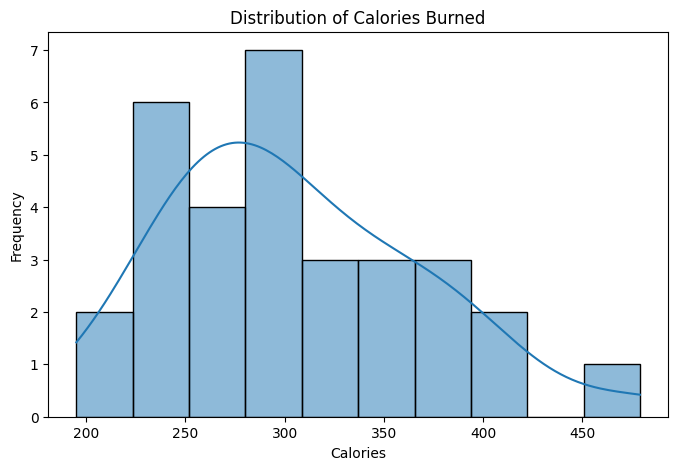

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(df["Calories"], bins=10, kde=True)

plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.title("Distribution of Calories Burned")

plt.show()

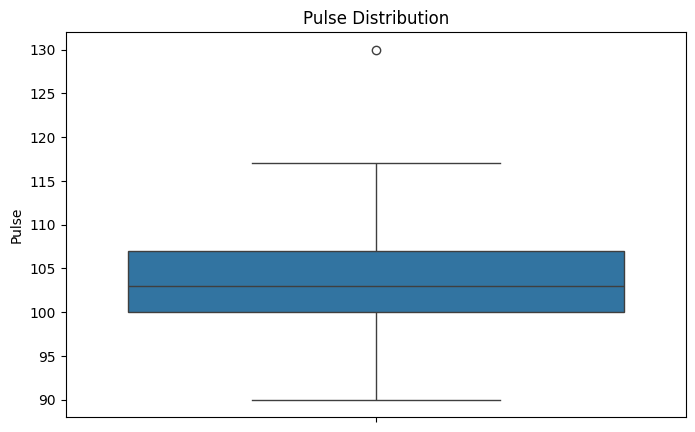

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(y=df["Pulse"])

plt.ylabel("Pulse")
plt.title("Pulse Distribution")

plt.show()

In [39]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Rows: 31
Columns: 7

Missing values:
Duration               0
Date                   0
Pulse                  0
Maxpulse               0
Calories               0
Calories_per_Minute    0
Pulse_Category         0
dtype: int64

Duplicate rows: 0


In [40]:
df.to_csv("cleaned_data.csv", index=False)